Saving pizza_sales.csv to pizza_sales (2).csv
Перші 5 рядків таблиці:
   pizza_id  order_id  pizza_name_id  quantity order_date order_time  \
0       1.0       1.0     hawaiian_m       1.0   1/1/2015   11:38:36   
1       2.0       2.0  classic_dlx_m       1.0   1/1/2015   11:57:40   
2       3.0       2.0  five_cheese_l       1.0   1/1/2015   11:57:40   
3       4.0       2.0    ital_supr_l       1.0   1/1/2015   11:57:40   
4       5.0       2.0     mexicana_m       1.0   1/1/2015   11:57:40   

   unit_price  total_price pizza_size pizza_category  \
0       13.25        13.25          M        Classic   
1       16.00        16.00          M        Classic   
2       18.50        18.50          L         Veggie   
3       20.75        20.75          L        Supreme   
4       16.00        16.00          M         Veggie   

                                   pizza_ingredients  \
0           Sliced Ham, Pineapple, Mozzarella Cheese   
1  Pepperoni, Mushrooms, Red Onions, Red Peppers

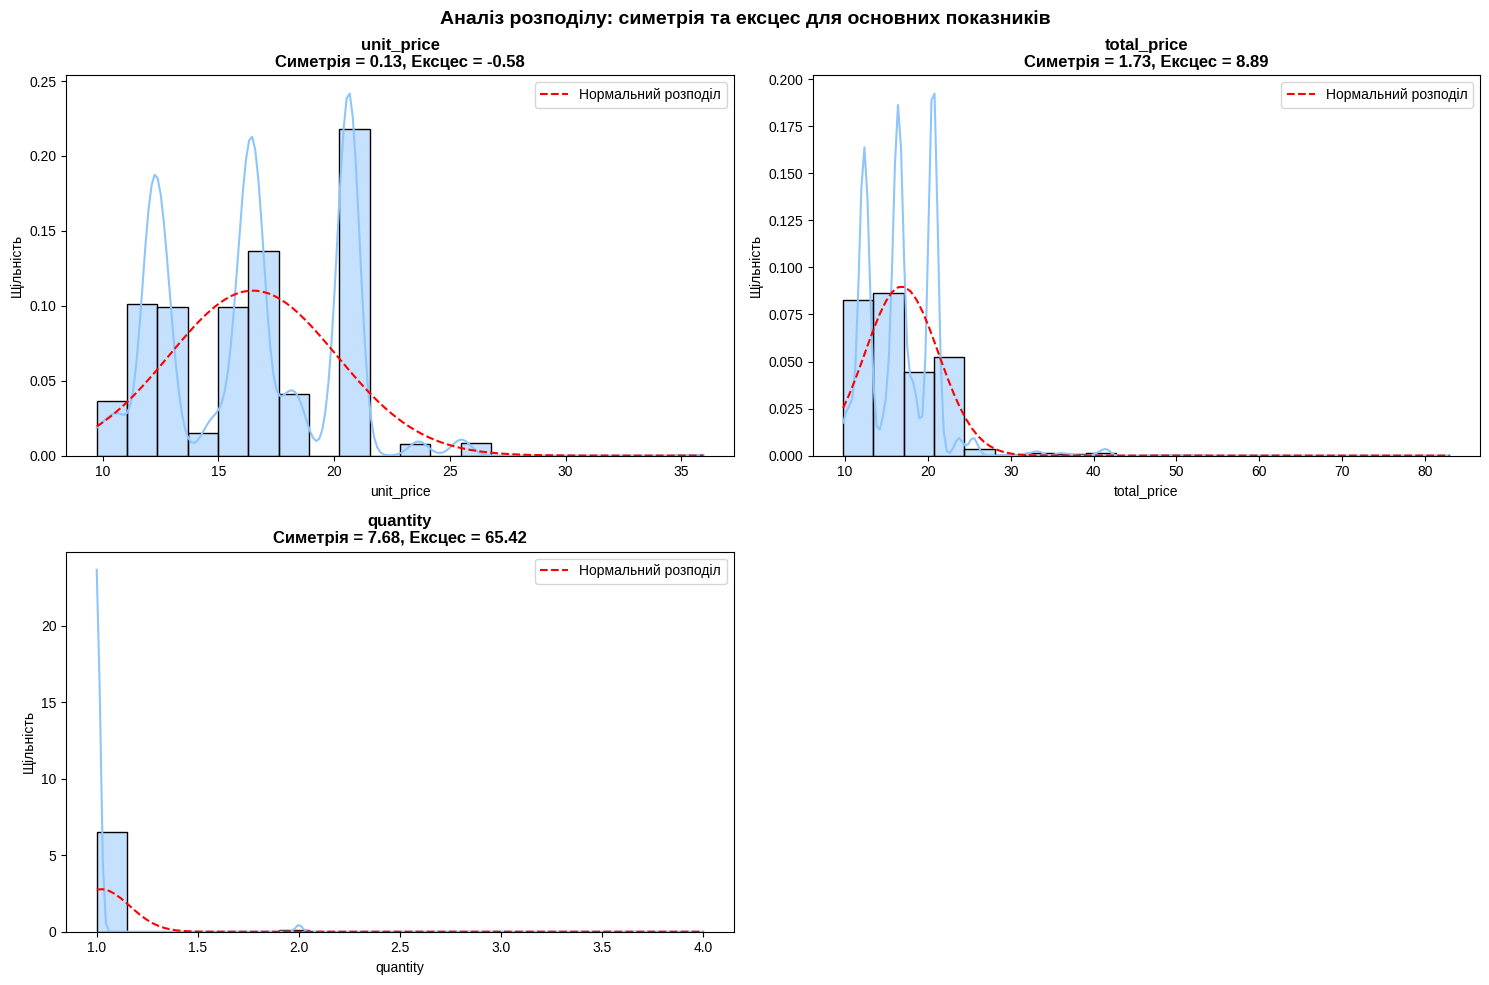


 Дисперсія для основних показників:
- Для вибірки кількостей піц в замовленні → 0.02
- Для вибірки цін за одну піцу → 13.12
- Для вибірки загальних вартостей замовлень → 19.69

 Стандартне відхилення (σ) для основних показників:
- Для вибірки кількостей піц в замовленні → σ = 0.14
- Для вибірки цін за одну піцу → σ = 3.62
- Для вибірки загальних вартостей замовлень → σ = 4.44

 Середнє відхилення (Mean Absolute Deviation):
- Для вибірки кількостей піц в замовленні → 0.04
- Для вибірки цін за одну піцу → 2.97
- Для вибірки загальних вартостей замовлень → 3.27

 Розмах варіації (max - min):
- Для вибірки кількостей піц в замовленні → 3.00
- Для вибірки цін за одну піцу → 26.20
- Для вибірки загальних вартостей замовлень → 73.25


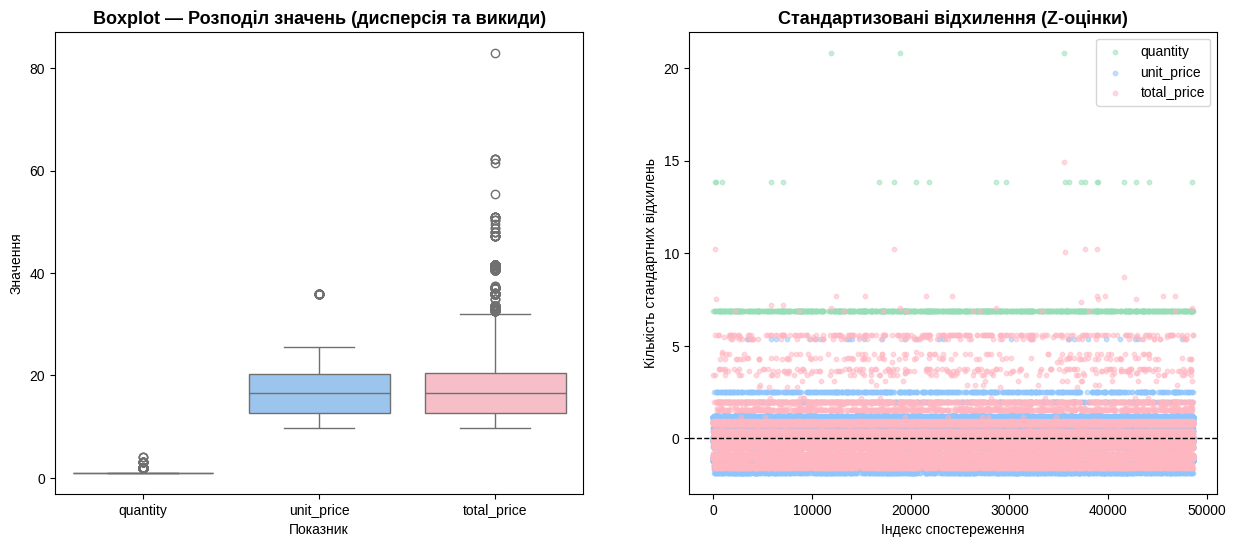

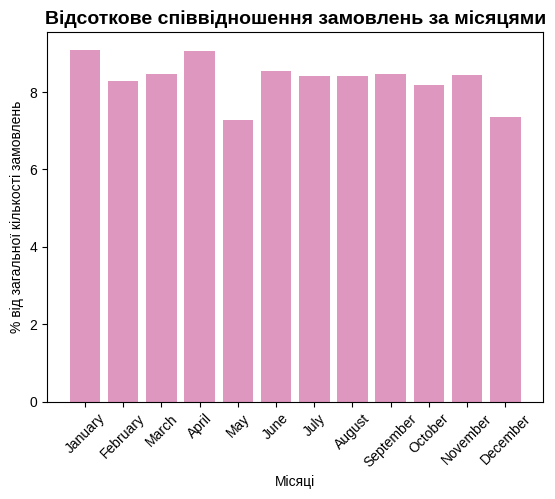

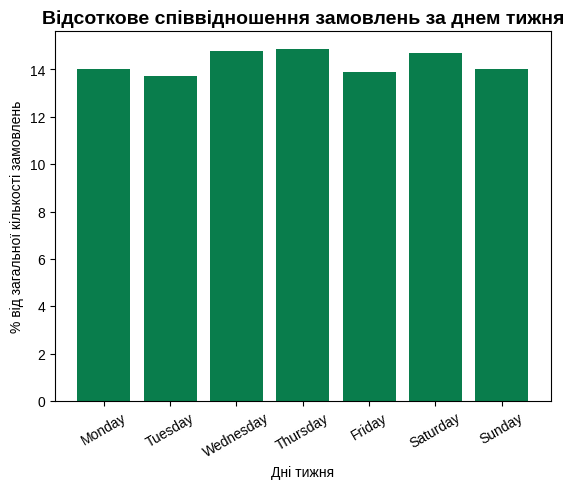

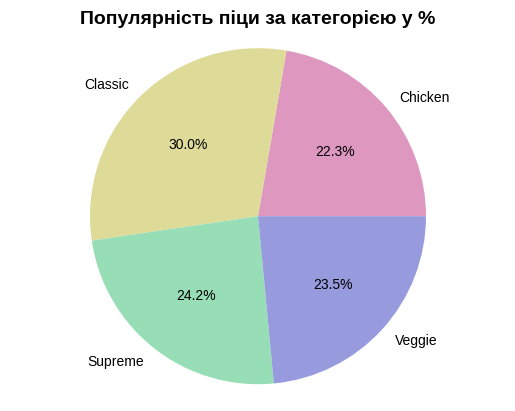

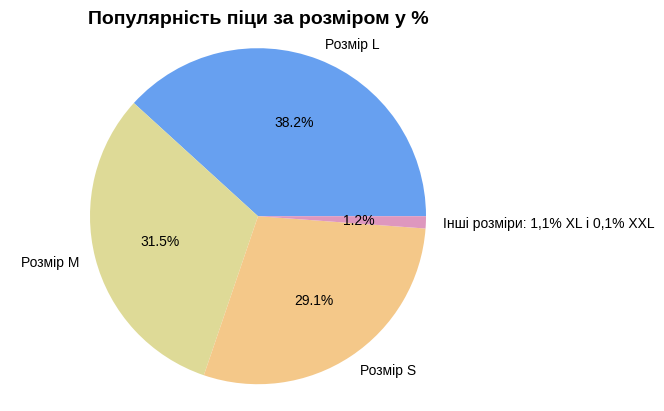

Унікальних піц у датасеті: 32


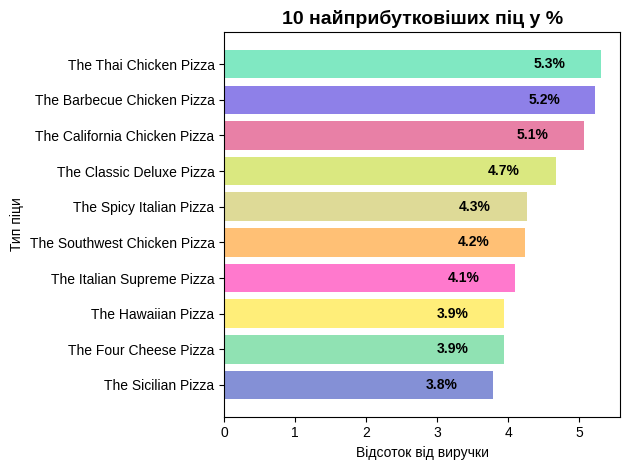

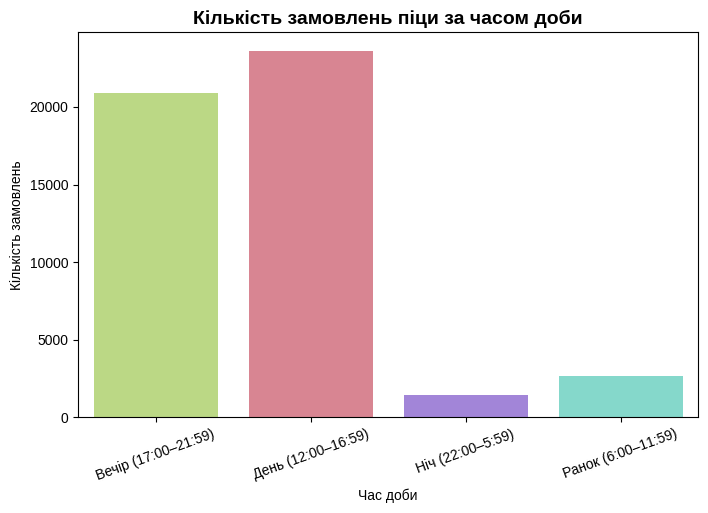

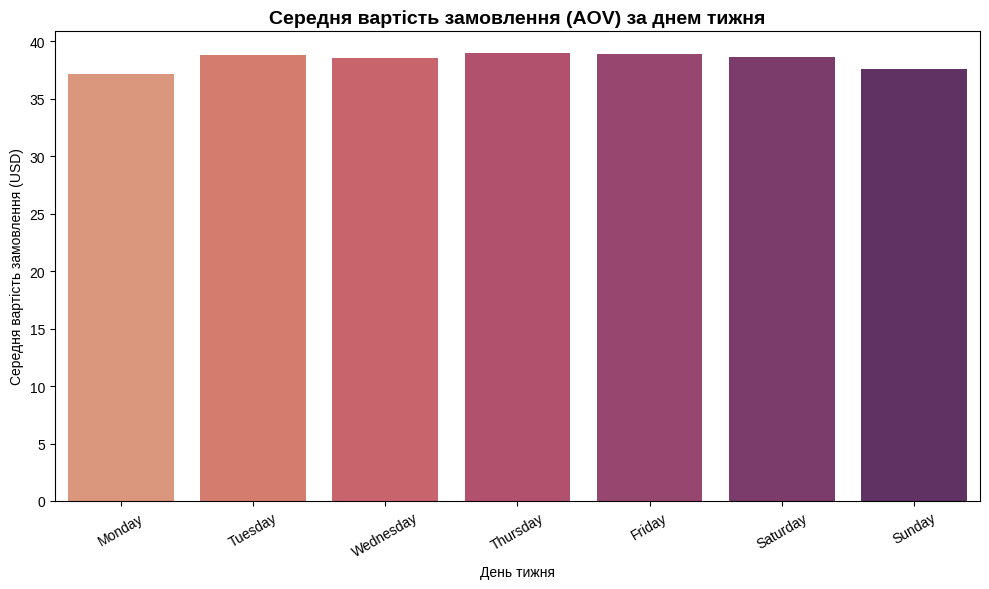

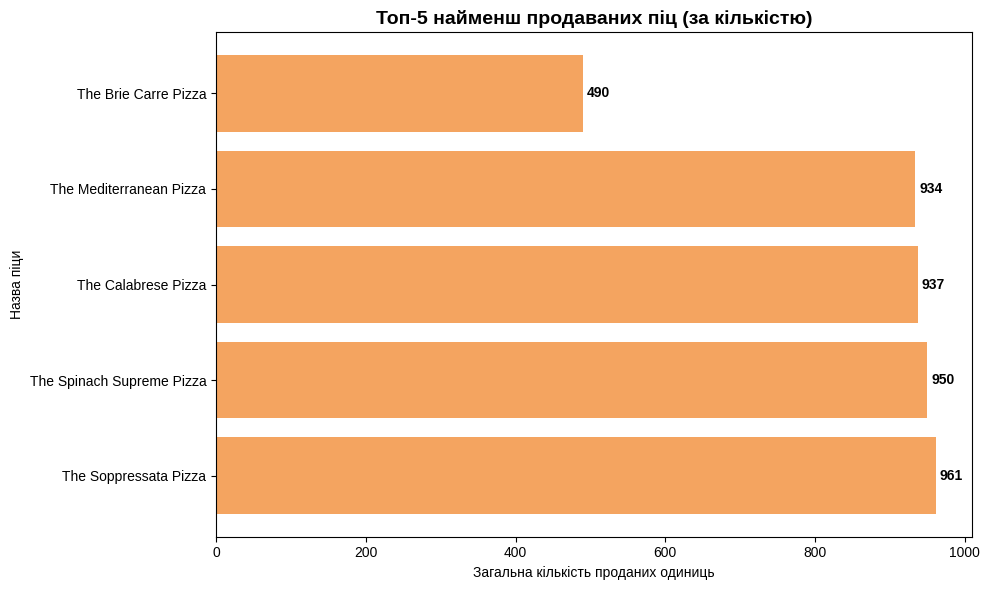


Середня вартість замовлення (AOV) за днем тижня:
                   AOV
Day of Week           
Monday       37.201498
Tuesday      38.840832
Wednesday    38.596725
Thursday     38.951961
Friday       38.933096
Saturday     38.650437
Sunday       37.561586

Топ-5 найменш продаваних піц (за кількістю):
                           Total Quantity Sold
Pizza Name                                    
The Brie Carre Pizza                     490.0
The Mediterranean Pizza                  934.0
The Calabrese Pizza                      937.0
The Spinach Supreme Pizza                950.0
The Soppressata Pizza                    961.0


In [ ]:
import pandas as pd #table
import matplotlib.pyplot as plt #graphics
import seaborn as sb #graphics
import seaborn as sns
import numpy as np #math
from scipy.stats import norm #norm rospodil


plt.rcParams['font.family'] = 'Liberation Sans' ## шрифт для всіх графіків
plt.rcParams['font.size'] = 10  ## розмір шрифта для всіх графіків
plt.rcParams['axes.titlesize'] = 14 ## розмір заголовка для всіх графіків
plt.rcParams['axes.titleweight'] = 'bold' ## розмір заголовка для всіх графіків

from google.colab import files
import pandas as pd

# діалогове вікно, яке дозволить користувачу вибрати файл для завантаження
uploaded = files.upload()

# отримуємо назву завантаженого файлу
file_name = list(uploaded.keys())[0]

# завантажуємо дані в DataFrame
df = pd.read_csv(file_name)

df.head() ## виведемо перші 10 рядків таблиці
print("Перші 5 рядків таблиці:")
print(df.head(), "\n")

df.shape ## дізнаємось, скільки рядків і стовпчиків
print("Розмір таблиці (скільки рядків та стовпців):", df.shape, "\n")

df.columns
print("Назви всіх стовпців:")
print(df.columns.tolist(), "\n") ## з нового рядка вставляємо всі назви стовпців

df.dtypes
print("Типи даних для кожної змінної:")
print(df.dtypes, "\n")

df.isnull().sum()
print("Кількість пропущених значень у кожному стовпці:")
print(df.isnull().sum(), "\n")

df[df['unit_price'] <= 0]
print("Кількість рядків з некоректною ціною за піцу (<=0):")
print(df[df['unit_price'] <= 0], "\n")

df[df['total_price'] <= 0]
print("Кількість рядків з некоректною ціною за все замовлення (<=0):")
print(df[df['total_price'] <= 0], "\n")

df[df['quantity'] <= 0]
print("Кількість рядків з некоректною кількістю замовлень (<=0):")
print(df[df['quantity'] <= 0], "\n")

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce') ## перетворюємо дату (order_date) у формат datetime, якщо помилка - формат зміниться на Not A Time
print(df['order_date'].head())
print(df['order_date'].dtypes) ## перевіримо, чи правильно перетворився формат

df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S', errors='coerce') ## перетворюємо текстовий час у datetime
print(df['order_time'].head())
print(df['order_time'].dtypes) ## перевіримо, чи правильно перетворився формат




          ## Проаналізуємо середні значення, моду, медіану, симетрію та ексцес, дисперсію, стандартне відхилення і розмах для стовпців unit_price, total_price, quantity
# Середнє, медіана і мода для стовпців unit_price та total_price
mean_unit = df['unit_price'].mean()
median_unit = df['unit_price'].median()
mode_unit = df['unit_price'].mode()[0]  # беремо перше значення, якщо мод декілька

mean_total = df['total_price'].mean()
median_total = df['total_price'].median()
mode_total = df['total_price'].mode()[0]
mean_quantity = df['quantity'].mean()
median_quantity = df['quantity'].median()
mode_quantity = df['quantity'].mode()[0]

print("Статистичні показники для кількості піц у замовленні (quantity):")
print(f"Середнє: {mean_quantity:.2f}")
print(f"Медіана: {median_quantity:.2f}")
print(f"Мода: {mode_quantity}\n")

print("Статистичні показники для ціни за одну піцу (unit_price):")
print(f"Середнє: {mean_unit:.2f}")
print(f"Медіана: {median_unit:.2f}")
print(f"Мода: {mode_unit:.2f}\n")

print("Статистичні показники для загальної вартості замовлення (total_price):")
print(f"Середнє: {mean_total:.2f}")
print(f"Медіана: {median_total:.2f}")
print(f"Мода: {mode_total:.2f}\n")
from scipy.stats import skew, kurtosis

# Симетрія (skewness) Показує, чи розподіл даних є симетричним навколо середнього значення.
skew_unit = skew(df['unit_price'])
skew_total = skew(df['total_price'])
skew_quantity = skew(df['quantity'])

# Ексцес (kurtosis) Вимірює, наскільки “гострий” або “плоский” розподіл порівняно з нормальним.
kurt_unit = kurtosis(df['unit_price'])
kurt_total = kurtosis(df['total_price'])
kurt_quantity = kurtosis(df['quantity'])

print("Показники симетрії та ексцесу:")

print(f"- Для вибірки цін за одну піцу →  симетрія: {skew_unit:.2f}, ексцес: {kurt_unit:.2f}")
print(f"- Для вибірки загальних вартостей замовлень → симетрія: {skew_total:.2f}, ексцес: {kurt_total:.2f}")
print(f"- Для вибірки кількостей піц в замовленні → симетрія: {skew_quantity:.2f}, ексцес: {kurt_quantity:.2f}")


# Створимо список змінних для аналізу
variables = ['unit_price', 'total_price', 'quantity']

plt.figure(figsize=(15, 10))

for i, var in enumerate(variables, 1):
    plt.subplot(2, 2, i) #підграфік

    # Обчислюємо статистичні показники
    data = df[var].dropna() #видаляє порожні значення
    skew_val = skew(data)
    kurt_val = kurtosis(data)

    # Будуємо гістограму з кривою нормального розподілу
    sns.histplot(data, kde=True, color='#8EC5FC', bins=20, stat='density', edgecolor='black')

    # Додаємо криву нормального розподілу для порівняння
    x = np.linspace(data.min(), data.max(), 100)
    plt.plot(x, norm.pdf(x, data.mean(), data.std()), color='red', linestyle='--', label='Нормальний розподіл')

    plt.title(f'{var}\nСиметрія = {skew_val:.2f}, Ексцес = {kurt_val:.2f}', fontsize=12, fontweight='bold')
    plt.xlabel(var)
    plt.ylabel('Щільність')
    plt.legend()

plt.suptitle('Аналіз розподілу: симетрія та ексцес для основних показників', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



# Розрахунок дисперсії (варіації) для основних показників

# Формула дисперсії: D(X) = Σ(xi - x̄)² / (n - 1)
# У pandas це обчислюється методом .var()
var_quantity = df['quantity'].var()
var_unit_price = df['unit_price'].var()
var_total_price = df['total_price'].var()
print("\n Дисперсія для основних показників:")
print(f"- Для вибірки кількостей піц в замовленні → {var_quantity:.2f}")
print(f"- Для вибірки цін за одну піцу → {var_unit_price:.2f}")
print(f"- Для вибірки загальних вартостей замовлень → {var_total_price:.2f}")

# Розрахунок стандартного відхилення для основних показників
# Стандартне відхилення — це квадратний корінь з дисперсії
# У pandas воно обчислюється методом .std()
std_quantity = df['quantity'].std()
std_unit_price = df['unit_price'].std()
std_total_price = df['total_price'].std()
print("\n Стандартне відхилення (σ) для основних показників:")
print(f"- Для вибірки кількостей піц в замовленні → σ = {std_quantity:.2f}")
print(f"- Для вибірки цін за одну піцу → σ = {std_unit_price:.2f}")
print(f"- Для вибірки загальних вартостей замовлень → σ = {std_total_price:.2f}")

# Середнє лінійне відхилення (Mean Absolute Deviation)
mad_quantity = (df['quantity'] - df['quantity'].mean()).abs().mean()
mad_unit_price = (df['unit_price'] - df['unit_price'].mean()).abs().mean()
mad_total_price = (df['total_price'] - df['total_price'].mean()).abs().mean()
print("\n Середнє відхилення (Mean Absolute Deviation):")
print(f"- Для вибірки кількостей піц в замовленні → {mad_quantity:.2f}")
print(f"- Для вибірки цін за одну піцу → {mad_unit_price:.2f}")
print(f"- Для вибірки загальних вартостей замовлень → {mad_total_price:.2f}")
# Розрахунок розмаху варіації для основних показників
range_quantity = df['quantity'].max() - df['quantity'].min()
range_unit_price = df['unit_price'].max() - df['unit_price'].min()
range_total_price = df['total_price'].max() - df['total_price'].min()
print("\n Розмах варіації (max - min):")
print(f"- Для вибірки кількостей піц в замовленні → {range_quantity:.2f}")
print(f"- Для вибірки цін за одну піцу → {range_unit_price:.2f}")
print(f"- Для вибірки загальних вартостей замовлень → {range_total_price:.2f}")


# Візуалізація дисперсії (розкиду даних)
variables = ['quantity', 'unit_price', 'total_price']

plt.figure(figsize=(15, 6))

# 1) Boxplot — показує медіану, квартили, "вуса" та викиди
plt.subplot(1, 2, 1)
sns.boxplot(data=df[variables], palette=['#97DEB7', '#8EC5FC', '#FFB6C1'])
plt.title('Boxplot — Розподіл значень (дисперсія та викиди)', fontsize=13, fontweight='bold')
plt.ylabel('Значення')
plt.xlabel('Показник')

# 2) Відхилення від середнього (розсіювання навколо 0)
# 2 # Стандартизовані відхилення (Z-оцінки)
plt.subplot(1, 2, 2)
for var, color in zip(variables, ['#97DEB7', '#8EC5FC', '#FFB6C1']):
    # ЗМІНА: Розрахунок Z-оцінки (стандартизація)
    # Z = (Значення - Середнє) / Стандартне відхилення
    std_dev = df[var].std()
    # Запобігання діленню на нуль, якщо std_dev дорівнює 0 (наприклад, для констант)
    if std_dev != 0:
        z_scores = (df[var] - df[var].mean()) / std_dev
    else:
        # Якщо дисперсія нульова, Z-оцінки дорівнюють 0
        z_scores = df[var] - df[var].mean()

    plt.scatter(range(len(z_scores)), z_scores, alpha=0.5, label=var, s=10, color=color) #розсіювальний графік

plt.axhline(0, color='black', linestyle='--', linewidth=1)
# Зміна: Оновлення заголовку та підпису осі Y
plt.title('Стандартизовані відхилення (Z-оцінки)', fontsize=13, fontweight='bold')
plt.xlabel('Індекс спостереження')
plt.ylabel('Кількість стандартних відхилень')
plt.legend()
plt.show()




## Для подальшого аналізу нам потрібні кілька нових стовпчиків, створимо їх:
## Стовпець для години замовлення:
df['order_hour'] = df['order_time'].dt.hour
## Стовпець для днів тижня:
df['order_day_of_week'] = df['order_date'].dt.day_name()
## Стовпець для місяців:
df['order_month'] = df['order_date'].dt.month_name()
## Перевіримо, чи відображаються вони в табличці, переглянемо перші 10 рядків:
df[['order_date', 'order_hour', 'order_day_of_week', 'order_month']].head(10)


        ## Перший параметр аналізу -- Проаналізуємо сезонність продажів за місяцями:
## групуємо всі замовлення за місяцем і рахуємо, скільки замовлень зроблено в кожному місяці
## робимо, щоб місяці були в хронологічному порядку (від січня до грудня)
sales_by_month = df.groupby('order_month')['order_id'].count().reindex(['January','February','March','April','May','June','July','August','September','October','November','December']).reset_index() ## робимо новий датафрейм із чистими індексами
sales_by_month.columns = ['Month', 'Orders']
## перетворимо наші значення на відсотки від загальної кількості замовлень:
sales_by_month['Percent'] = sales_by_month['Orders'] / sales_by_month['Orders'].sum() * 100
## Створюємо стовпчикову діаграму:
plt.bar(sales_by_month['Month'], sales_by_month['Percent'], color = '#DE97BE')
plt.xticks(rotation=45) ## щоб назви місяців не накладались
plt.title('Відсоткове співвідношення замовлень за місяцями') ## назва діаграми
plt.ylabel('% від загальної кількості замовлень') ## назва вісі у
plt.xlabel('Місяці') ## вісі х
plt.show()


          ## Другий параметр аналізу -- Проаналізуємо кількість продажів за днем тижня:
## групуємо всі замовлення за днем тижня і рахуємо, скільки замовлень зроблено кожного дня
## робимо, щоб дні були в правильному порядку (від понеділка до неділі)
sales_by_day = df.groupby('order_day_of_week')['order_id'].nunique()
sales_by_day = sales_by_day.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
sales_by_day = sales_by_day.reset_index()
sales_by_day.columns = ['Day of week', 'Orders']
## перетворимо наші значення на відсотки від загальної кількості замовлень:
sales_by_day['Percent'] = sales_by_day['Orders'] / sales_by_day['Orders'].sum() * 100
## Створюємо стовпчикову діаграму:
plt.bar(sales_by_day['Day of week'], sales_by_day['Percent'], color = '#097d4c')
plt.xticks(rotation=30) ## щоб назви днів не накладались
plt.title('Відсоткове співвідношення замовлень за днем тижня') ## назва діаграми
plt.ylabel('% від загальної кількості замовлень') ## назва вісі у
plt.xlabel('Дні тижня') ## вісі х
plt.show()

          ## Третій параметр аналізу -- Проаналізуємо, яка піца з усіх категорій є найпопулярнішою:
## визначаємо суму, скільки піц замовляли якої категорії
category_popularity = df.groupby('pizza_category')['quantity'].sum().reset_index()
category_popularity['Percent'] = category_popularity['quantity'] / category_popularity['quantity'].sum() * 100
## створимо pie chart, autopct = додавання відсотків на сектори з одним знаком після коми
plt.pie(category_popularity['Percent'], labels = category_popularity['pizza_category'], autopct = '%1.1f%%', colors = ['#DE97BE', '#DEDA97', '#97DEB7', '#979BDE'])
plt.title('Популярність піци за категорією у %') ## назва діаграми
plt.axis('equal')
plt.show()

            ## Четвертий параметр аналізу -- Проаналізуємо, яка піца з усіх розмірів є найпопулярнішою:
## визначаємо суму, скільки піц замовляли якого розміру
size_popularity = df.groupby('pizza_size')['quantity'].sum().reset_index()
size_popularity['Percent'] = size_popularity['quantity'] / size_popularity['quantity'].sum() * 100
## оскільки сектори для розмірів XL i XXL будуть дуже малими, варто обʼєднати їх в одну категорію "Інші розміри"
## Тому вводимо поріг для "малих" секторів
threshold = 5  # менше 5% - об'єднуємо
size_popularity['size_grouped'] = size_popularity.apply(lambda row: row['pizza_size'] if row['Percent'] >= threshold else 'Інші розміри: 1,1% XL i 0,1% XXL', axis=1)

size_grouped = size_popularity.groupby('size_grouped')['quantity'].sum().reset_index()
size_grouped['Percent'] = size_grouped['quantity'] / size_grouped['quantity'].sum() * 100

## створимо pie chart, autopct = додавання відсотків на сектори з одним знаком після коми
plt.pie(size_grouped['Percent'], labels = ['Розмір ' + s if s != 'Інші розміри: 1,1% XL i 0,1% XXL' else 'Інші розміри: 1,1% XL i 0,1% XXL' for s in size_grouped['size_grouped']]
, autopct = '%1.1f%%', colors = ['#67A0F0', '#DEDA97', '#F4C889', '#DE97BE'])
plt.title('Популярність піци за розміром у %') ## назва діаграми
plt.axis('equal')
plt.show()


            ## Пʼятий параметр аналізу -- Проаналізуємо, які піци є найбільш прибутковими
## порахуємо, скільки в нас унікальних типів піци
num_pizzas = df['pizza_name'].nunique()
print("Унікальних піц у датасеті:", num_pizzas)
## оскільки 32 типи це доволі багато, створимо кругову діаграму з 10 найбільш прибутковими видами піц
# сумарний дохід з кожного виду піци, сортуємо від найбільшого до найменшого
total_revenue = df['total_price'].sum()
top_revenue_pizzas = df.groupby('pizza_name')['total_price'].sum().sort_values(ascending=False).head(10).reset_index()
# відсоток від загальної виручки
top_revenue_pizzas['Percent'] = top_revenue_pizzas['total_price'] / total_revenue * 100
## тепер створимо діаграму для 10 найприбутковіших
bars = plt.barh(top_revenue_pizzas['pizza_name'], top_revenue_pizzas['Percent'], color = ['#80E8C2', '#8E80E8', '#E880A6', '#DAE880', '#DEDA97', '#FFC075', '#FF79CD', '#FFEE79', '#90E2B3' ,'#8490D6'])
plt.gca().invert_yaxis()  # щоб найприбутковіші були зверху
plt.title('10 найприбутковіших піц у %')
plt.xlabel('Відсоток від виручки')
plt.ylabel('Тип піци')
for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 0.5,                 ## розміщуємо текст на 0.5 лівіше від кінця стовпичка
        bar.get_y() + bar.get_height()/2,    ##знаходимо центр по осі У, і розмішуємо текст в центрі
        f'{width:.1f}%',             ## формат: 1 знак після коми + %
        va='center',
        ha='right',                  ## вирівнювання по правому краю
        color='black',
        fontweight='bold')
plt.tight_layout()
plt.show()

          ##Шостий параметр аналізу -- Проаналізуємо, в який час доби клієнти найчастіше замовляють піцу
# Класифікація годин замовлення за часом доби
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Ранок (6:00–11:59)'
    elif 12 <= hour < 17:
        return 'День (12:00–16:59)'
    elif 17 <= hour < 22:
        return 'Вечір (17:00–21:59)'
    else:
        return 'Ніч (22:00–5:59)'

# Створюємо новий стовпець із часовими інтервалами
df['time_of_day'] = df['order_hour'].apply(get_time_of_day)
# Підрахунок кількості замовлень у кожному інтервалі
orders_by_time = df['time_of_day'].value_counts().reset_index()
orders_by_time.columns = ['Time of Day', 'Orders']
orders_by_time = orders_by_time.sort_values('Time of Day')
# Створюємо графік
plt.figure(figsize=(8,5))
sns.barplot(x='Time of Day', hue='Time of Day', y='Orders', data=orders_by_time, palette =['#BFE677', '#E67788', '#9E77E6', '#77E6D5'])
plt.title('Кількість замовлень піци за часом доби', fontsize=14, fontweight='bold')
plt.xlabel('Час доби')
plt.ylabel('Кількість замовлень')
plt.xticks(rotation=20)
plt.show()

# Сьомий параметр аналізу - Аналіз середньої вартості замовлення (Average Order Value - AOV) за днем тижня

# 1. Розрахунок загальної вартості для кожного унікального замовлення
order_revenue = df.groupby('order_id')['total_price'].sum().reset_index()
order_revenue.columns = ['order_id', 'order_revenue']

# 2. Додавання дня тижня до таблиці замовлень (використовуємо лише унікальні order_id)
# стовпець 'order_day_of_week' вже існує
orders_with_day = df[['order_id', 'order_day_of_week']].drop_duplicates(subset=['order_id'])

# 3. Об'єднання даних про дохід із днями тижня
aov_df = pd.merge(orders_with_day, order_revenue, on='order_id')

# 4. Розрахунок AOV (середнє значення доходу) за днем тижня
aov_by_day = aov_df.groupby('order_day_of_week')['order_revenue'].mean().reset_index()
aov_by_day.columns = ['Day of Week', 'AOV']

# 5. Визначення хронологічного порядку днів
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
aov_by_day.dropna(subset=['Day of Week'], inplace=True)
aov_by_day['Day of Week'] = pd.Categorical(aov_by_day['Day of Week'], categories=day_order, ordered=True)
aov_by_day = aov_by_day.sort_values('Day of Week')

# 6. Візуалізація
plt.figure(figsize=(10, 6))
sns.barplot(x='Day of Week', y='AOV', data=aov_by_day, palette='flare', hue='Day of Week', dodge=False, legend=False)

plt.title('Середня вартість замовлення (AOV) за днем тижня', fontsize=14, fontweight='bold')
plt.xlabel('День тижня')
plt.ylabel('Середня вартість замовлення (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Восьмий параметр аналізу - Аналіз 5 найменш продаваних піц за кількістю

# 1. Об'єднання даних за назвою піци та сумою проданої кількості
bottom_pizzas = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=True).head(5).reset_index()
bottom_pizzas.columns = ['Pizza Name', 'Total Quantity Sold']

# 2. Візуалізація (горизонтальна гістограма для кращої читабельності назв)
plt.figure(figsize=(10, 6))
bars = plt.barh(bottom_pizzas['Pizza Name'], bottom_pizzas['Total Quantity Sold'], color='#F4A460')
plt.gca().invert_yaxis() # Щоб найменш продавана була зверху

plt.title('Топ-5 найменш продаваних піц (за кількістю)', fontsize=14, fontweight='bold')
plt.xlabel('Загальна кількість проданих одиниць')
plt.ylabel('Назва піци')

# Додавання підписів даних
for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va='center', ha='left', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

# Виведення результатів
print("\nСередня вартість замовлення (AOV) за днем тижня:")
print(aov_by_day.set_index('Day of Week'))
print("\nТоп-5 найменш продаваних піц (за кількістю):")
print(bottom_pizzas.set_index('Pizza Name'))


In [ ]:
display (df.head())

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_hour,order_day_of_week,order_month,time_of_day
0,1.0,1.0,hawaiian_m,1.0,2015-01-01,1900-01-01 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,11,Thursday,January,Ранок (6:00–11:59)
1,2.0,2.0,classic_dlx_m,1.0,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,11,Thursday,January,Ранок (6:00–11:59)
2,3.0,2.0,five_cheese_l,1.0,2015-01-01,1900-01-01 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,11,Thursday,January,Ранок (6:00–11:59)
3,4.0,2.0,ital_supr_l,1.0,2015-01-01,1900-01-01 11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,11,Thursday,January,Ранок (6:00–11:59)
4,5.0,2.0,mexicana_m,1.0,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,11,Thursday,January,Ранок (6:00–11:59)
